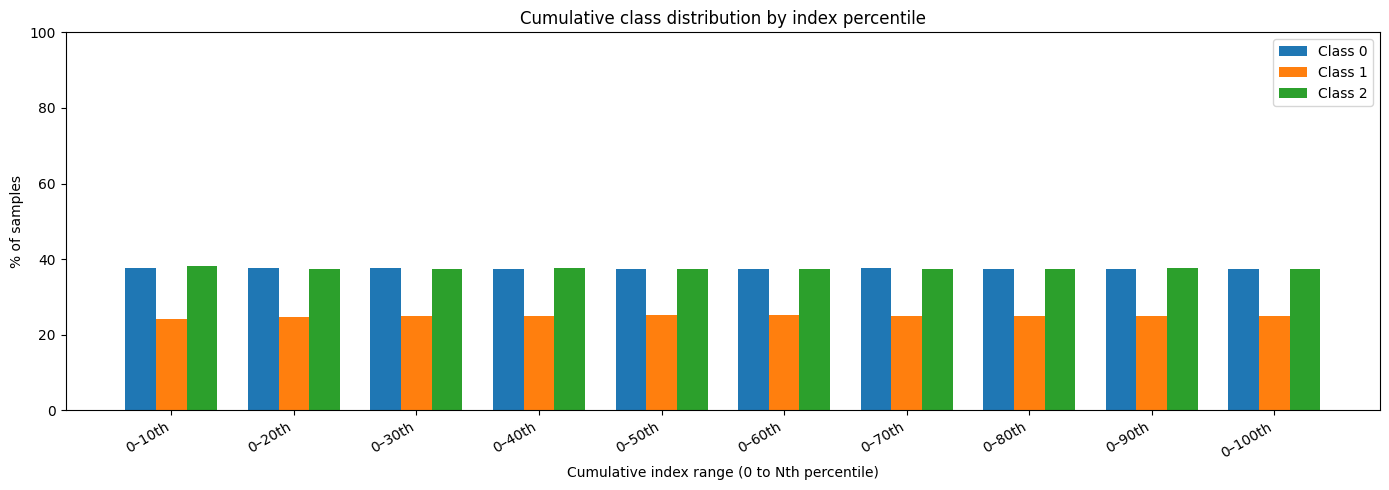

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load & preprocess (same as main script)
labels_data = pd.read_csv('LD2_dataset/labels.csv', dtype={'Image': str, 'class_label': int})
labels_data = labels_data[~labels_data['class_label'].isin([5, 8])]

label_map = {0: 0, 2: 0, 4: 0, 3: 1, 6: 1, 1: 2, 7: 2, 9: 2}
labels_data['class_label'] = labels_data['class_label'].map(label_map)
labels_data = labels_data.reset_index(drop=True)

n = len(labels_data)
classes = sorted(labels_data['class_label'].unique())
percentiles = range(10, 110, 10)  # 10, 20, ..., 100

# For each percentile p, compute class % in rows 0..p%
pct = {cls: [] for cls in classes}
for p in percentiles:
    cutoff = int(n * p / 100)
    subset = labels_data.iloc[:cutoff]
    counts = subset['class_label'].value_counts()
    total = len(subset)
    for cls in classes:
        pct[cls].append(counts.get(cls, 0) / total * 100)

# Plot
x = np.arange(len(percentiles))
width = 0.25
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(14, 5))
for i, cls in enumerate(classes):
    ax.bar(x + i * width, pct[cls], width, label=f'Class {cls}', color=colors[i])

ax.set_xlabel('Cumulative index range (0 to Nth percentile)')
ax.set_ylabel('% of samples')
ax.set_title('Cumulative class distribution by index percentile')
ax.set_xticks(x + width)
ax.set_xticklabels([f'0–{p}th' for p in percentiles], rotation=30, ha='right')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()
